# 📊 Supermarket Sales & Business Analytics
### AICTE | IBM SkillsBuild Data Analytics with AI Internship
- **Author:** Md Sameer Khan
- **Institution:** Maharaja Agrasen Institute of Technology
- **Dataset:** SuperMarket Analysis - Copy.csv
- **Objective:** Exploratory Data Analysis, Revenue Optimization, Customer Segmentation, and Channel Insights

Import Libraries

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 4.5)
print("Libraries imported successfully!")

Libraries imported successfully!


Load & Inspect Dataset

In [44]:
# Load dataset
df = pd.read_csv("SuperMarket Analysis - Copy.csv")

print(f"Total Transactions: {df.shape[0]}")
print(f"Total Features/Columns: {df.shape[1]}")
df.head(5)

Total Transactions: 1000
Total Features/Columns: 17


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


Data Preprocessing & Missing Values Check

In [45]:
# Check for null values
print("Missing values per column:")
print(df.isnull().sum())

# Convert Date to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Dataset summary statistics
df[['Unit price', 'Quantity', 'Sales', 'Rating']].describe()

Missing values per column:
Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64


,Unit price,Quantity,Sales,Rating
count,1000.000000,1000.000000,1000.000000,1000.00000
mean,55.672130,5.510000,322.966749,6.97270
std,26.494628,2.923431,245.885335,1.71858
min,10.080000,1.000000,10.678500,4.00000
25%,32.875000,3.000000,124.422375,5.50000
50%,55.230000,5.000000,253.848000,7.00000
75%,77.935000,8.000000,471.350250,8.50000
max,99.960000,10.000000,1042.650000,10.00000


Core KPI Metrics

In [46]:
total_revenue = df['Sales'].sum()
avg_spend = df['Sales'].mean()
total_tx = len(df)
avg_rating = df['Rating'].mean()

print(f"Total Gross Revenue: ${total_revenue:,.2f}")
print(f"Total Orders: {total_tx:,}")
print(f"Average Spend per Transaction: ${avg_spend:,.2f}")
print(f"Average Customer Satisfaction: {avg_rating:.2f} / 10.0")

Total Gross Revenue: $322,966.75
Total Orders: 1,000
Average Spend per Transaction: $322.97
Average Customer Satisfaction: 6.97 / 10.0


Chart 1: Revenue by Product Line

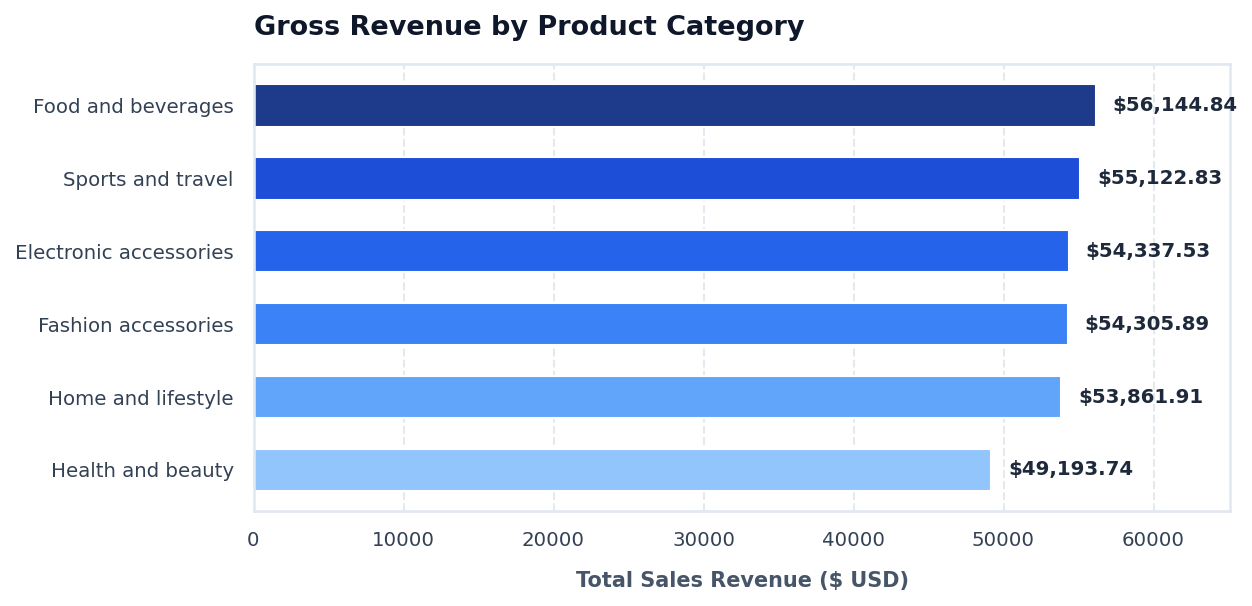

In [47]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(8.5, 4.2), dpi=150)
cat_sales = df.groupby('Product line')['Sales'].sum().sort_values(ascending=True)
palette = ['#93C5FD', '#60A5FA', '#3B82F6', '#2563EB', '#1D4ED8', '#1E3A8A']
bars = ax.barh(cat_sales.index, cat_sales.values, color=palette, height=0.58)

ax.set_title("Gross Revenue by Product Category", fontsize=13, fontweight='bold', color='#0F172A', pad=14, loc='left')
ax.set_xlabel("Total Sales Revenue ($ USD)", fontsize=10, fontweight='semibold', color='#475569', labelpad=10)
ax.tick_params(colors='#334155', labelsize=9.5)
ax.xaxis.grid(True, linestyle='--', alpha=0.5, color='#CBD5E1')
ax.yaxis.grid(False)
ax.set_axisbelow(True)

for bar in bars:
    w = bar.get_width()
    ax.text(w + 1100, bar.get_y() + bar.get_height()/2, f"${w:,.2f}", 
            va='center', ha='left', fontsize=9.5, fontweight='bold', color='#1E293B')

ax.set_xlim(0, max(cat_sales.values) * 1.16)
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_color('#E2E8F0')

plt.tight_layout()
plt.show()

Chart 2: Customer Spend Distribution (Loyalty Member vs. Normal)

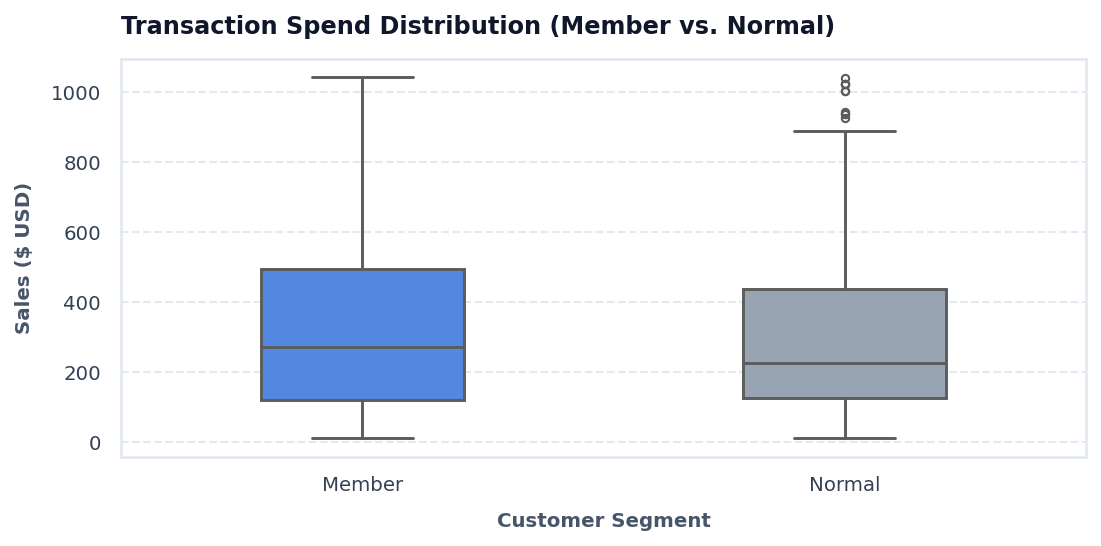

In [48]:
import warnings
warnings.filterwarnings('ignore')

fig, ax = plt.subplots(figsize=(7.5, 3.8), dpi=150)
sns.boxplot(data=df, x='Customer type', y='Sales', palette=['#3B82F6', '#94A3B8'], 
            width=0.42, linewidth=1.4, fliersize=3.5, ax=ax)

ax.set_title("Transaction Spend Distribution (Member vs. Normal)", fontsize=11.5, fontweight='bold', color='#0F172A', pad=12, loc='left')
ax.set_xlabel("Customer Segment", fontsize=9.5, fontweight='semibold', color='#475569', labelpad=8)
ax.set_ylabel("Sales ($ USD)", fontsize=9.5, fontweight='semibold', color='#475569', labelpad=8)
ax.tick_params(colors='#334155', labelsize=9.5)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='#CBD5E1')
ax.xaxis.grid(False)
ax.set_axisbelow(True)

for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_color('#E2E8F0')

plt.tight_layout()
plt.show()

Chart 3: Store Branch Performance & Customer Spend

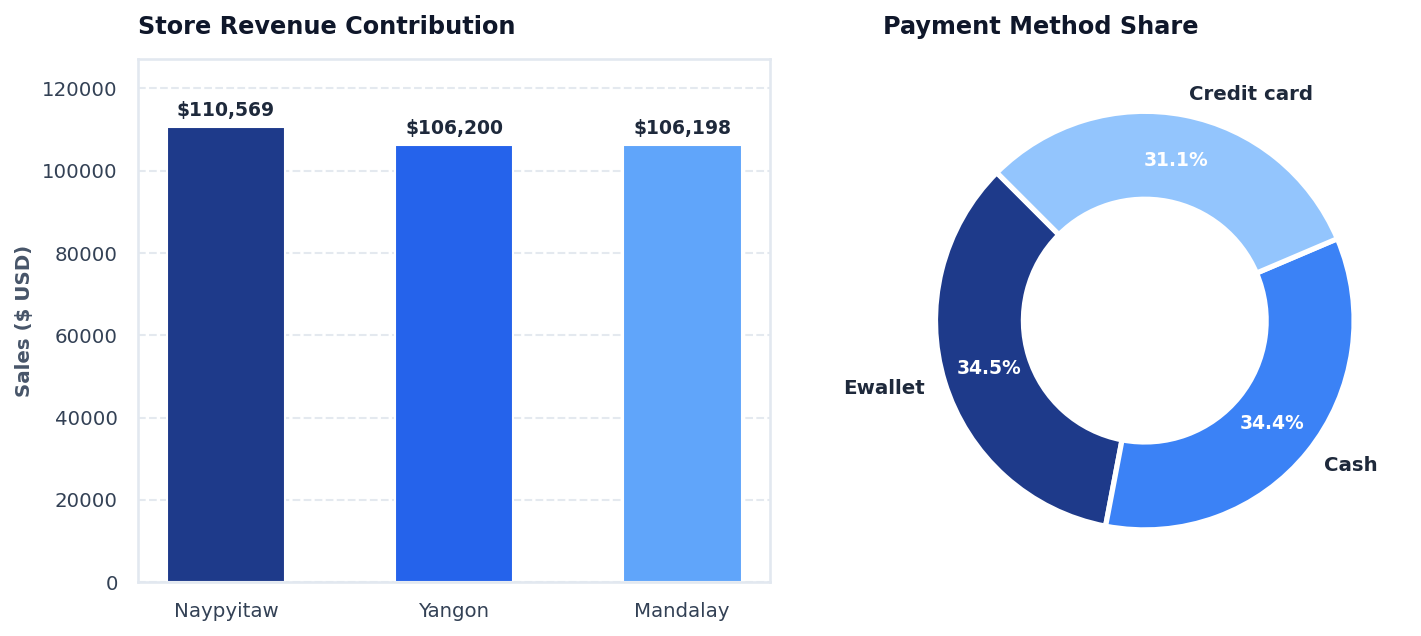

In [49]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.4), dpi=150)

# 1. Branch Revenue Bar Chart
branch_sales = df.groupby('City')['Sales'].sum().reindex(['Naypyitaw', 'Yangon', 'Mandalay'])
city_palette = ['#1E3A8A', '#2563EB', '#60A5FA']
bars_city = ax1.bar(branch_sales.index, branch_sales.values, color=city_palette, width=0.52)
ax1.set_title("Store Revenue Contribution", fontsize=11.5, fontweight='bold', color='#0F172A', pad=12, loc='left')
ax1.set_ylabel("Sales ($ USD)", fontsize=9.5, fontweight='semibold', color='#475569')
ax1.tick_params(colors='#334155', labelsize=9.5)
ax1.yaxis.grid(True, linestyle='--', alpha=0.5, color='#CBD5E1')
ax1.xaxis.grid(False)
ax1.set_axisbelow(True)

for bar in bars_city:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 1800, f"${h:,.0f}", 
             ha='center', va='bottom', fontsize=9, fontweight='bold', color='#1E293B')

ax1.set_ylim(0, max(branch_sales.values) * 1.15)
for spine in ['top', 'right', 'left', 'bottom']:
    ax1.spines[spine].set_color('#E2E8F0')

# 2. Payment Method Donut Chart
pay_data = df['Payment'].value_counts()
pay_colors = ['#1E3A8A', '#3B82F6', '#93C5FD']
wedges, texts, autotexts = ax2.pie(pay_data, labels=pay_data.index, autopct='%1.1f%%', 
                                  startangle=135, colors=pay_colors, pctdistance=0.78,
                                  textprops={'fontsize': 9.5, 'color': '#1E293B', 'fontweight': 'semibold'},
                                  wedgeprops=dict(width=0.42, edgecolor='white', linewidth=2.5))
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(9)

ax2.set_title("Payment Method Share", fontsize=11.5, fontweight='bold', color='#0F172A', pad=12, loc='left')

plt.tight_layout()
plt.show()